In [ ]:
#############################################
## MATPLOTLIB FEATURES
%matplotlib inline
import matplotlib 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
font = {'weight' : 'bold','size'   : 22}
mpl.rc('font', **font)
mpl.rc('font',   size=209)  #set defaults so that the plots are readable
mpl.rc('axes',   titlesize=20)
mpl.rc('axes',   labelsize=20)
mpl.rc('xtick',  labelsize=20)
mpl.rc('ytick',  labelsize=20)
mpl.rc('legend', fontsize =20)
mpl.rc('figure', titlesize=20)
mpl.rc('text',   usetex=True)
## FURTHER MATPLOTLIB FEATURES
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
font_dict = {'family': 'serif', 'color':  None,  'weight': 'bold','size': 30}
#############################################
import os,sys,time
from copy import deepcopy as dcopy
from scipy import interpolate
from scipy import integrate
import numpy as np
import healpy as hp
import camb
from camb import model, initialpower
#############################################
import warnings
warnings.filterwarnings("ignore")
#############################################
#PATH TO SCRIPTS FOLDER
path = '/data/AMARINS/LSSxHI-CODES/scripts/'
sys.path.insert(1, path)
import cross_functions_theory      as cxft

In [ ]:
#definitions
c_light = 299792458/1e3 #km/s
nu_HI  = 1420.405751768 #MHz

In [ ]:
#halofit_version
#
#original: astro-ph/0207664
#bird: arXiv:1109.4416
#peacock: Peacock fit
#takahashi: arXiv:1208.2701
#mead: HMCode arXiv:1602.02154
#halomodel: basic halomodel
#casarini: PKequal arXiv:0810.0190, arXiv:1601.07230
#mead2015: original 2015 version of HMCode arXiv:1505.07833
#mead2016: Alias for ‘mead’.
#mead2020: 2020 version of HMcode arXiv:2009.01858
#mead2020_feedback: 2020 version of HMcode with baryonic feedback arXiv:2009.01858

params = { 'H0'   : 67.5,
           'ombh2': 0.022,
           'omch2': 0.122,
           'ns'   : 0.965,
           'z'    : np.logspace(np.log10(1),np.log10(1150), 150),
           'kmax' : 100,
           'minkh': 1e-4,
           'maxkh': 100,
           'npoints': 1e8,
           'nonlinear':True,
           'halofit_version':'mead2020'}       


#pars = camb.CAMBparams()
pars = camb.set_params(halofit_version=params['halofit_version'])#, HMCode_A_baryon=3.13, HMCode_eta_baryon=0.603, HMCode_logT_AGN=7.8)
                       #H0=params['H0'], ombh2=params['ombh2'], omch2=params['omch2'])
pars.set_cosmology(H0=params['H0'], ombh2=params['ombh2'], omch2=params['omch2'])
pars.InitPower.set_params(ns=params['ns'])
pars.set_matter_power(redshifts=params['z'], kmax=params['kmax'])
#pars.NonLinear = model.NonLinear_both
#results.calc_power_spectra(pars)
results   = camb.get_results(pars)
pk_interp = camb.get_matter_power_interpolator(pars, 
                                               nonlinear=params['nonlinear'], hubble_units=False, k_hunit=False, 
                                               kmax=params['kmax'], zmax=params['z'][-1])
print('done!')

Note: redshifts have been re-sorted (earliest first)


In [ ]:
gpars = cxft.load_survey_parameters(survey_name = 'LSST', data_release='Y10', type_field='density', mode = 'photometric',path_file='/data/AMARINS/LSSxHI-CODES/scripts/parameters/lsst_desc_parameters.yaml')

In [ ]:
gpars

{'survey': 'LSST',
 'data_release': 'Y10',
 'field': 'density',
 'mode': 'photometric',
 'z_min': 0.01,
 'z_max': 3.5,
 'limiting_magnitude': 25.3,
 'sigma_z': 0.05,
 'z_bias': 0.0,
 'n_tomo_bins': 5,
 'nbins': 5,
 'beta': 2.0,
 'alpha': 0.68,
 'z_0': 0.11,
 'mean_eff_z': 1.05,
 'n_gal': 27.0}

In [6]:
dNdz_vec = cxft.dNdz_func(pars=gpars, binning=1,  verbose=False, type_field=gpars['field'])
dNdz_vec.keys()

dict_keys(['dNdz', 'z'])

In [7]:
zrange   = np.linspace(gpars['z_min'], gpars['z_max'], 500)
dNdz_vec = np.array([ cxft.nz_spec(pars=gpars)(ix) for ix in zrange ])
cxft.source_bins_lsst(redshift_range=zrange, redshift_distribution=dNdz_vec, dens_pars=gpars).keys()

dict_keys([0, 1, 2, 3, 4])

In [8]:
bins = cxft.compute_equal_number_bounds_lsst(redshift_range=zrange, redshift_distribution=dNdz_vec, n_bins=gpars["n_tomo_bins"])
print('bin edges: ',np.around(bins, decimals=2))

bin edges:  [0.01 0.45 0.72 1.03 1.51 3.5 ]


In [9]:
#bias and variance values for each bin
source_z_bias_list     = np.repeat(gpars["z_bias"] , gpars["n_tomo_bins"])
source_z_variance_list = np.repeat(gpars["sigma_z"], gpars["n_tomo_bins"])
print('bias for each bin: ', np.around(source_z_bias_list, decimals=2))
print('var  for each bin: ', np.around(source_z_variance_list, decimals=2))

bias for each bin:  [0. 0. 0. 0. 0.]
var  for each bin:  [0.05 0.05 0.05 0.05 0.05]


In [10]:
# Create a dictionary of the redshift distributions for each bin
dNdz_dict = {}
# Loop over the bins: each bin is defined by the upper and lower edge of the bin
for index, (x1, x2) in enumerate(zip(bins[:-1], bins[1:])):
    z_bias     = source_z_bias_list[index]
    z_variance = source_z_variance_list[index]
    dNdz_dict[index] = cxft.true_redshift_distribution_lsst(upper_edge=x1, 
                                                                                    lower_edge=x2, 
                                                                                    bias=z_bias, 
                                                                                    variance=z_variance,
                                                                                    redshift_range=zrange, 
                                                                                    redshift_distribution=dNdz_vec)
dNdz_tot = dNdz_dict[0]+dNdz_dict[1]+dNdz_dict[2]+\
           dNdz_dict[3]+dNdz_dict[4]    
np.trapz(y=dNdz_tot, x=zrange)

1.642019900488036

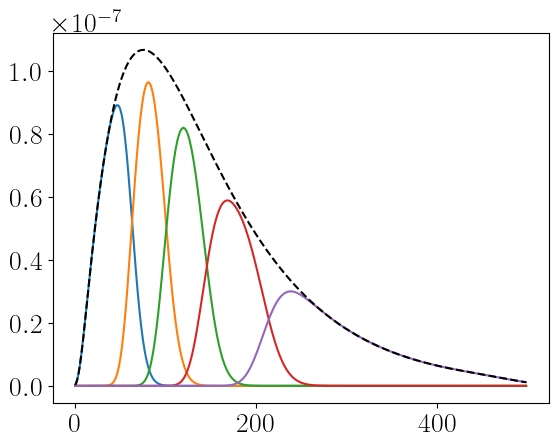

In [11]:
fact=1/(np.degrees(1)*60)**2
plt.plot(fact*dNdz_dict[0])
plt.plot(fact*dNdz_dict[1])
plt.plot(fact*dNdz_dict[2])
plt.plot(fact*dNdz_dict[3])
plt.plot(fact*dNdz_dict[4])
plt.plot(fact*dNdz_tot, ls='dashed',c='black');

In [12]:
dNdz_dict = cxft.source_bins_lsst(redshift_range=zrange, redshift_distribution=dNdz_vec, dens_pars=gpars)
for i,iz in enumerate(dNdz_dict.keys()):
    if not i: dNdz_tot = dcopy(dNdz_dict[iz])
    else: dNdz_tot += dcopy(dNdz_dict[iz])

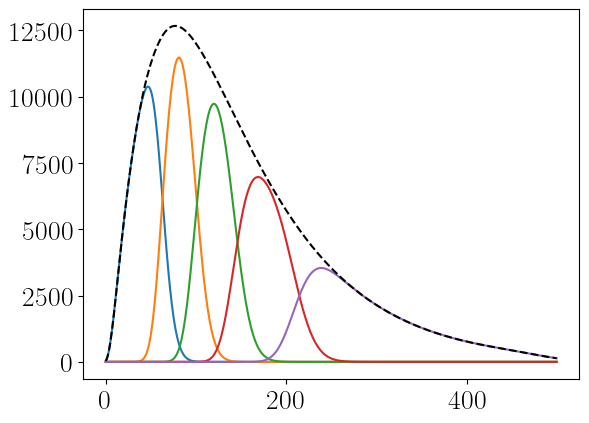

In [13]:
fact=(np.degrees(1))**2
plt.plot(fact*dNdz_dict[0])
plt.plot(fact*dNdz_dict[1])
plt.plot(fact*dNdz_dict[2])
plt.plot(fact*dNdz_dict[3])
plt.plot(fact*dNdz_dict[4])
plt.plot(fact*dNdz_tot, ls='dashed',c='black');

In [14]:
np.degrees(1)#1rad in deg
(np.degrees(1)*60)#1rad in arcmin

3437.746770784939

In [15]:
np.trapz(y=fact*dNdz_tot, x=zrange)

16413.991008866236

In [17]:
#np.trapz(y=source_redshift_distribution_dict[0], x=zrange)*60

In [18]:
#np.trapz(y=source_redshift_distribution_dict[1], x=zrange)*60

In [19]:
z = np.linspace(0., 3., 1024)
i_lim = 26. # Limiting i-band magnitude
z0 = 0.0417 * i_lim - 0.744

ell = np.arange(2, 2000)
delta_ell = ell[1] - ell[0]
Ngal = 46. * 100.31 * (i_lim - 25.) # Normalisation, galaxies/arcmin^2
pz = 1. / (2. * z0) * (z / z0)**2. * np.exp(-z / z0) # Redshift distribution, p(z)
dNdz = Ngal * pz # Number density distribution


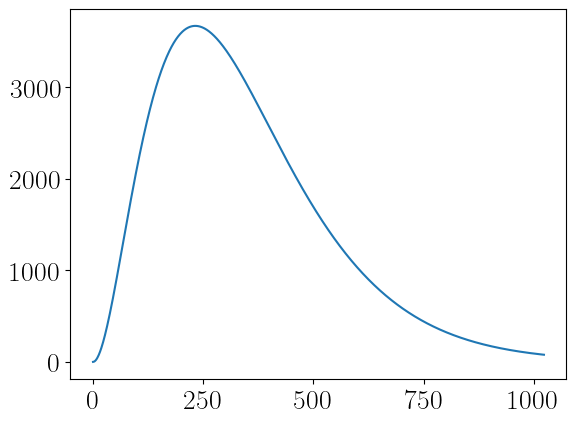

In [20]:
plt.plot(dNdz)

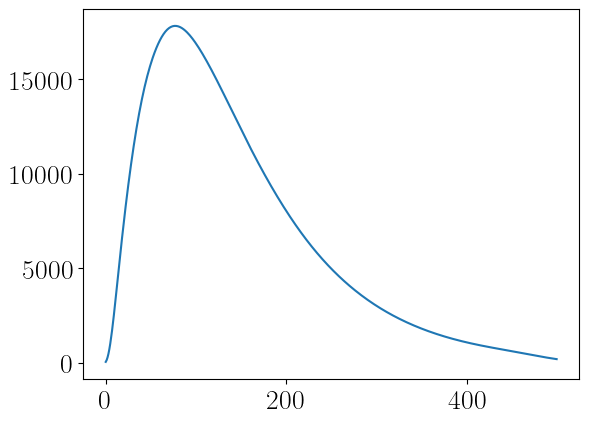

In [21]:
plt.plot(Ngal*dNdz_tot)

In [22]:
#degrees2=degrees_squared
#arcmin2=arcminute_squared
arcmin=1
arcmin2=arcmin**2
degrees2 = arcmin2/(60*60)
# Convert degrees squared to steradians
steradians = degrees2 * (np.pi / 180) ** 2
steradians

8.461594994075239e-08